In [28]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

import tqdm

import sys
import os

In [29]:

#########################################################
################@Copyright from sandilabs################
#########################################################
def generate_gamma_sparse(n_sys, neurons_per_mesh_point, gamma_norm):   
    '''
    Generates the Gamma matrix mapping neurons to readout variables.  
    n_sys: number of readout variables
    neurons_per_mesh_point: number of neurons to place at each mesh node
    gamma_norm:  Magnitude of the readout kernel for each neuron
    
    '''
    
    n_neurons = neurons_per_mesh_point * n_sys

    gamma_data = []
    gamma_row = []
    gamma_col = []
    for pt in range(n_sys):
      
        start_idx = pt * neurons_per_mesh_point
        half_npm = neurons_per_mesh_point//2
        
        gamma_row.extend(neurons_per_mesh_point*[pt])
        gamma_col.extend(list(range(start_idx, start_idx + neurons_per_mesh_point)))
        gamma_data.extend(half_npm*[-gamma_norm])
        gamma_data.extend(half_npm*[gamma_norm])
         
    return sp.sparse.csr_array((np.array(gamma_data), (np.array(gamma_row), np.array(gamma_col))), shape=(n_sys, n_neurons))

#########################################################
################@Copyright from sandilabs################
#########################################################
def create_spiking_fem_network_sparse(A_sys, gamma, gamma_norm, lambda_d=10, lambda_v=20, mu=1e-6, nu=1e-5, tau_A=0.1):
    '''
    Generates sparse weight matrices, thresholds, and reset voltages for a NeuroFEM network implementing the
    linear system A_sys with readout kernel gamma
    '''
    n_sys, n_neurons = gamma.shape
    gTg = (gamma.T) @ gamma
    omega_f = gTg + mu*(lambda_d**2) * sp.sparse.eye_array(n_neurons)
    
    GTAG = (gamma.T) @ (A_sys / tau_A) @ gamma  # should be sparse
    
    threshs = 0.5 * (nu*lambda_d**2 + (gamma_norm**2) * np.ones(n_neurons))
    v_reset = threshs - (gamma_norm**2 + mu*(lambda_d**2)) * np.ones(n_neurons)
    omega_f = omega_f - (gamma_norm**2 + mu*(lambda_d**2)) * sp.sparse.eye_array(n_neurons)

    return omega_f, GTAG, threshs, v_reset



def read_csr_matrx(mtx_filename):
    try:
    
        raw_data = np.loadtxt(mtx_filename, skiprows=1, dtype=float)
        
        
        with open(mtx_filename, 'r') as f:
            header = f.readline().split()
            n_rows = int(header[0])
            n_cols = int(header[1])


        rows = raw_data[:, 0].astype(int) - 1
        cols = raw_data[:, 1].astype(int) - 1
        values = raw_data[:, 2]


        A = sp.sparse.csr_matrix((values, (rows, cols)), shape=(n_rows, n_cols))


        initial_nnz = A.nnz
        A.eliminate_zeros()
        print(f"Shape: {A.shape}")
        print(f"Non-zeros: {A.nnz}")

        return A
    except Exception as e:
        print(f"Failed to load matrix: {e}")
        sys.exit(1)



def read_vec(filename):
    try:
        b = np.loadtxt(filename, dtype=float, skiprows=1)
        return b
    except Exception as e:
        print(f"Failed to load RHS: {e}")
        sys.exit(1)

In [30]:
problem_name = "Sphere_00"
    
mtx_filename = f"{problem_name}_mtx.txt"
rhs_filename = f"{problem_name}_rhs.txt"
sol_filename = f"{problem_name}_sol.txt"

data_directory = "data/matrix/"

print(os.getcwd())

A = read_csr_matrx(data_directory + mtx_filename)
b = read_vec(data_directory + rhs_filename)
x_sol = read_vec("data/solution/" + sol_filename)

x_analytical = read_vec("data/solution/" + "Sphere_00_analytical_rhs.txt")



/home/amirbouslama/Documents/Studium/Neuromorphic-Lab-TUM/NeuromorphicSolver
Shape: (41, 41)
Non-zeros: 403


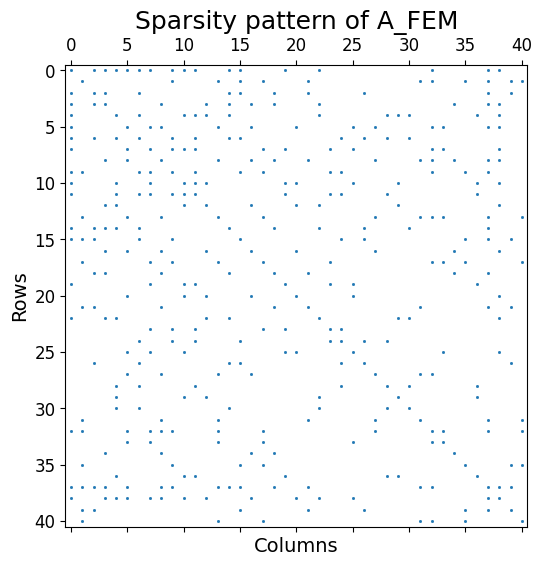

In [47]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(A, markersize=1)
plt.title("Sparsity pattern of A_FEM", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

In [32]:
#### Converting the matrix

#### The power of two defining the magnitude of gamma

############################################################
############# @Copyright from sandilabs ####################
############################################################
gamma_pow2 = -6 # In the paper, we used gamma = 2^-6 or gamma = 2^-8
s_gamma = 7 - gamma_pow2
gamma_norm = (2**gamma_pow2 - 2**-s_gamma)

#### The power of two to which we rescale the slow weight matrix
omega_s_pow2 = 1 
omega_max = 2**omega_s_pow2 - 2**-(7-omega_s_pow2)


#### network parameters
lambda_d = 8              # Hz; slow variable time constant.  Default = 10 Hz
lambda_v = 16             # Hz; membrane potential time constant. Default = 20 Hz

ki = 16                   # integral control gain
kp = 4                    # proportional control gain


N_interior = A.shape[0]
neurons_per_mesh_point = 4
n_neurons = neurons_per_mesh_point * N_interior
        
sigma_v = 0.00225 # We kept this constant for all meshes
tau_A = (gamma_norm**2) * np.amax(np.abs(A))/omega_max
mu = 0  # spike L2 norm penalization; set to 0
nu = 0  # spike L1 norm penalization; set to 0

# create system
gamma = generate_gamma_sparse(N_interior, neurons_per_mesh_point, gamma_norm)
# Added gamma_norm in the correct position
omega_f, GTAG, threshs, v_reset = create_spiking_fem_network_sparse(
    -A, 
    gamma, 
    gamma_norm, 
    lambda_d=lambda_d, 
    lambda_v=lambda_v, 
    mu=mu, 
    nu=nu, 
    tau_A=tau_A
)

dt = 2**(-12)             # power of two
n_timesteps = 100000

# neuron biases
bias_f1 = gamma.T @ (b / tau_A)


In [33]:
n_sys, n_neurons = gamma.shape

# Initialize variables
V = np.zeros(n_neurons)
spikes = np.zeros((n_neurons, 1), dtype=np.int8)
output = np.zeros((n_sys, n_timesteps))

# Feedback current (u1) and Integral error (u_int)
u1 = np.zeros(n_neurons)
u_int = np.zeros(n_neurons)

# This input is constant for a static Ax=b problem
c_in_fixed_gamma = np.copy(bias_f1)

print("Starting simulation...")
for step in tqdm.tqdm(range(1, n_timesteps)):
    

    du1 = dt * (-lambda_d * u1) + GTAG @ spikes[:, 0]
    u1 += du1


    u_err = u1 + c_in_fixed_gamma
    

    u_int += dt * u_err
        
    dv = dt * (-lambda_v * V + kp * u_err + ki * u_int) \
         - omega_f.dot(spikes[:, 0]) \
         + sigma_v * np.random.randn(n_neurons)
    V += dv
        

    spikes[:, 0] = np.greater(V, threshs).astype(np.int8)


    has_spiked = spikes[:, 0] > 0
    V[has_spiked] = v_reset[has_spiked]


    output[:, step] = (1 - dt * lambda_d) * output[:, step-1] + gamma.dot(spikes[:, 0])

Starting simulation...


100%|██████████| 99999/99999 [00:07<00:00, 13517.76it/s]


Final Relative Error: 7.1940e-01


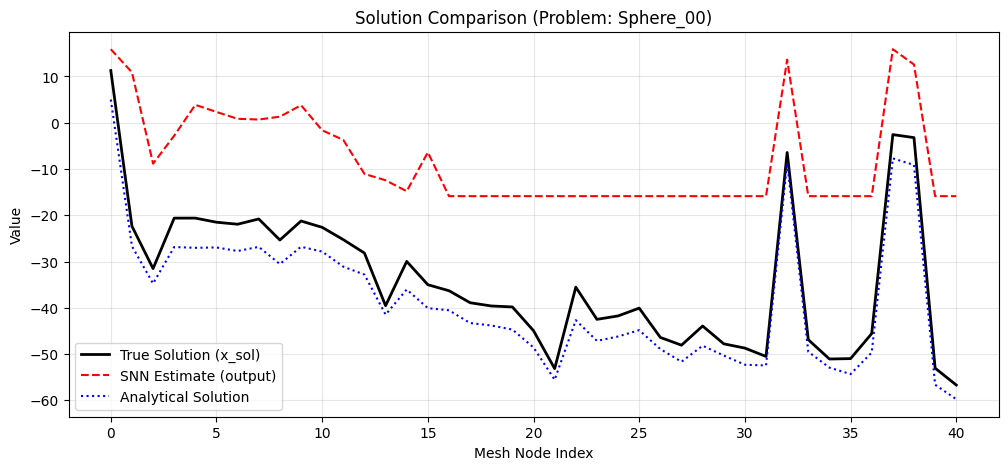

In [34]:

x_estimated = output[:, -1]


error_norm = np.linalg.norm(x_estimated - x_sol)
true_norm = np.linalg.norm(x_sol)
rel_error = error_norm / true_norm

print(f"========================================")
print(f"Final Relative Error: {rel_error:.4e}")
print(f"========================================")


plt.figure(figsize=(12, 5))


plt.plot(x_sol, 'k-', linewidth=2, label='True Solution (x_sol)')
plt.plot(x_estimated, 'r--', linewidth=1.5, label='SNN Estimate (output)')
plt.plot(x_analytical, 'b:', linewidth=1.5, label='Analytical Solution')
plt.title(f'Solution Comparison (Problem: {problem_name})')
plt.xlabel('Mesh Node Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)


In [35]:
diff = np.linalg.norm(x_estimated - x_sol)

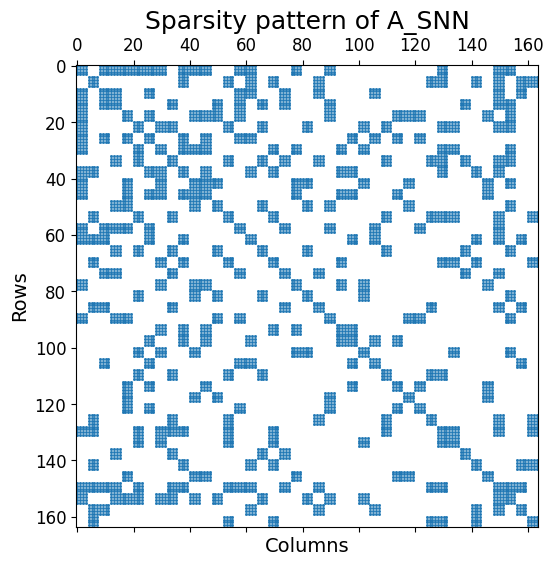

In [46]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(GTAG, markersize=1)
plt.title("Sparsity pattern of A_SNN", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

In [37]:
r = 19
sub_GA = GTAG[0:r, 0:r].toarray()



for i in range(r):
    for j in range(r):
        print(f"{sub_GA[i, j]:.2e} ", end="")
    print()

-1.89e+00 -1.89e+00 1.89e+00 1.89e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -6.19e-02 -6.19e-02 6.19e-02 6.19e-02 -2.50e-03 -2.50e-03 2.50e-03 2.50e-03 1.75e-01 1.75e-01 -1.75e-01 
-1.89e+00 -1.89e+00 1.89e+00 1.89e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -6.19e-02 -6.19e-02 6.19e-02 6.19e-02 -2.50e-03 -2.50e-03 2.50e-03 2.50e-03 1.75e-01 1.75e-01 -1.75e-01 
1.89e+00 1.89e+00 -1.89e+00 -1.89e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 6.19e-02 6.19e-02 -6.19e-02 -6.19e-02 2.50e-03 2.50e-03 -2.50e-03 -2.50e-03 -1.75e-01 -1.75e-01 1.75e-01 
1.89e+00 1.89e+00 -1.89e+00 -1.89e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 6.19e-02 6.19e-02 -6.19e-02 -6.19e-02 2.50e-03 2.50e-03 -2.50e-03 -2.50e-03 -1.75e-01 -1.75e-01 1.75e-01 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.45e+00 -1.45e+00 1.45e+00 1.45e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.45e+00 -1.45e+00 1.45e+00 1.45e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+0

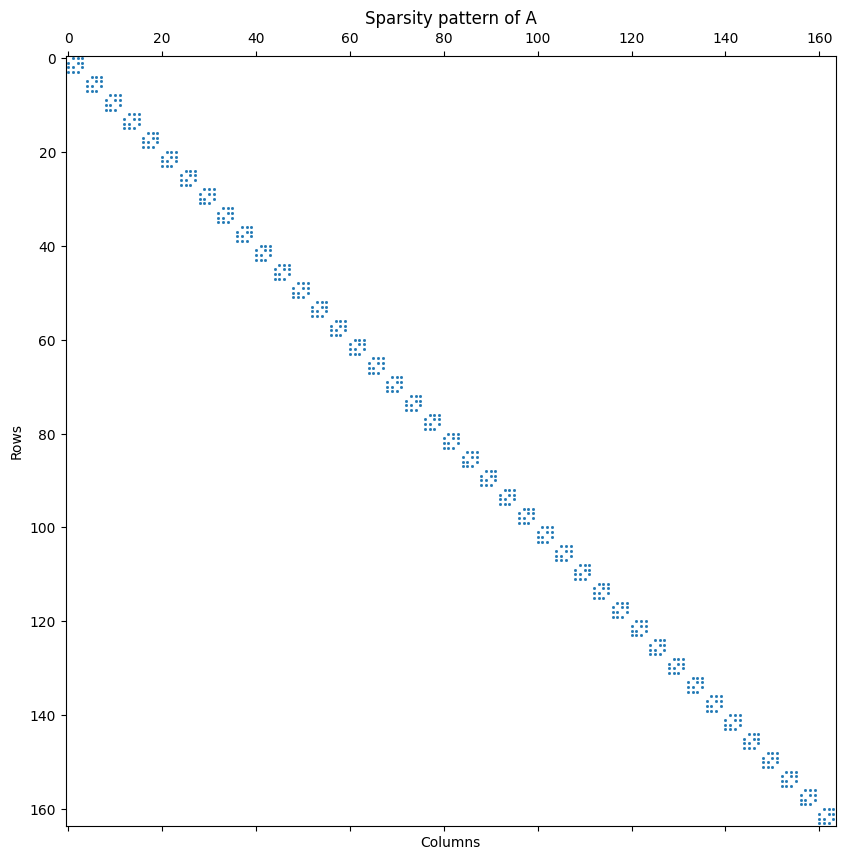

In [38]:
plt.figure(figsize=(10, 10))
plt.spy(omega_f, markersize=1)
plt.title("Sparsity pattern of A")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [39]:
sub_omega_f = omega_f[0:10, 0:10].toarray()

sub_omega_f

array([[ 0.        ,  0.00024034, -0.00024034, -0.00024034,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.00024034,  0.        , -0.00024034, -0.00024034,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.00024034, -0.00024034,  0.        ,  0.00024034,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.00024034, -0.00024034,  0.00024034,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.00024034, -0.00024034, -0.00024034,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.00024034,
         0.        , -0.00024034, -0.00024034,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.00024034,
        -0.00024034,  0.        ,  0.00024034

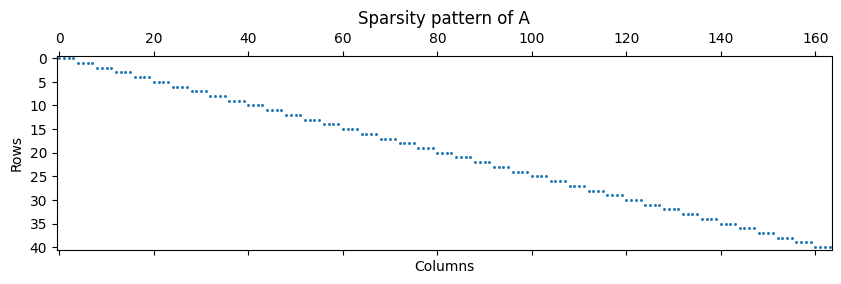

In [40]:
plt.figure(figsize=(10, 10))
plt.spy(gamma, markersize=1)
plt.title("Sparsity pattern of A")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [52]:
sub_gamma = gamma[0:10, 0:10].toarray()

sub_gamma

for i in range(10):
    for j in range(10):
        print(f"{sub_gamma[i, j]:.2e} ", end="")
    print()

-1.55e-02 -1.55e-02 1.55e-02 1.55e-02 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.55e-02 -1.55e-02 1.55e-02 1.55e-02 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.55e-02 -1.55e-02 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 
